Using Colab cache for faster access to the 'titanic-dataset' dataset.
Dataset downloaded to: /kaggle/input/titanic-dataset

First 5 Rows:
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101

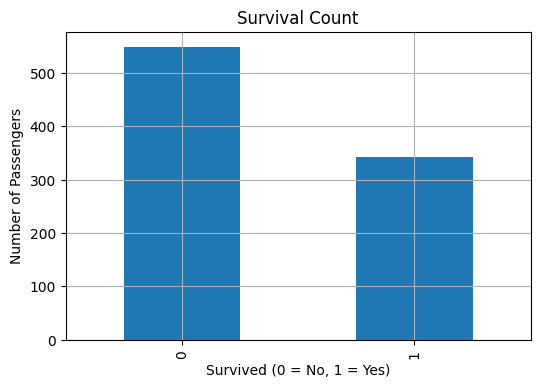


Prediction for Sample Passenger:
The passenger is likely to SURVIVE.


In [1]:
# Install KaggleHub (used to download the Titanic dataset)
!pip install kagglehub -q

# Import libraries
import kagglehub
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# Download Titanic dataset
path = kagglehub.dataset_download("yasserh/titanic-dataset")

print("Dataset downloaded to:", path)

# Load dataset
df = pd.read_csv(path + "/Titanic-Dataset.csv")

# Display first five rows
print("\nFirst 5 Rows:")
print(df.head())

# Display dataset information
print("\nDataset Information:")
print(df.info())

# Display statistical summary
print("\nStatistical Summary:")
print(df.describe())

# Handle missing values
df["Age"] = df["Age"].fillna(df["Age"].median())
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])

# Convert categorical columns into numerical values
df["Sex"] = df["Sex"].map({"male": 0, "female": 1})
df["Embarked"] = df["Embarked"].map({"S": 0, "C": 1, "Q": 2})

# Select features and target
features = ["Pclass", "Sex", "Age", "SibSp", "Parch", "Fare", "Embarked"]
X = df[features]
y = df["Survived"]

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train Logistic Regression model
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

# Make predictions
predictions = model.predict(X_test)

# Evaluate model
accuracy = accuracy_score(y_test, predictions)

print("\nModel Accuracy:", accuracy * 100)

print("\nClassification Report:")
print(classification_report(y_test, predictions))

# Plot survival count
plt.figure(figsize=(6,4))
df["Survived"].value_counts().plot(kind="bar")
plt.title("Survival Count")
plt.xlabel("Survived (0 = No, 1 = Yes)")
plt.ylabel("Number of Passengers")
plt.grid(True)
plt.show()

# Predict survival for a sample passenger
sample = pd.DataFrame({
    "Pclass": [3],
    "Sex": [1],       # Female
    "Age": [25],
    "SibSp": [0],
    "Parch": [0],
    "Fare": [7.25],
    "Embarked": [0]
})

prediction = model.predict(sample)

print("\nPrediction for Sample Passenger:")
if prediction[0] == 1:
    print("The passenger is likely to SURVIVE.")
else:
    print("The passenger is NOT likely to SURVIVE.")